# Lesson 1: Your First LangGraph

In this notebook you build the smallest useful LangGraph workflow:

1. Load and validate configuration from a `.env` file
2. Call a local LLM through the OpenAI-compatible client (Ollama)
3. Define a **state schema** that flows through the graph
4. Implement a **node** that calls the model
5. Wire nodes with **edges**
6. **Compile**, **visualize**, and **invoke** the graph

### Mental model

A LangGraph app is a directed graph where:

- **State** is a shared dictionary passed from node to node
- **Nodes** are Python functions that read state, do work, and return updated state
- **Edges** define execution order (`START` → node → `END`)
- **Compile** turns the graph definition into a runnable object
- **Invoke** runs the graph once with an initial state

## 1. Environment configuration

We keep secrets and runtime settings in `.env`:

| Variable | Purpose |
|----------|---------|
| `PROVIDER_URL` | Base URL of the OpenAI-compatible API (e.g. `http://localhost:11434/v1` for Ollama) |
| `MODEL_NAME` | Model tag served by the provider (e.g. `qwen3:8b`) |
| `API_KEY` | API key required by the client; Ollama accepts any non-empty placeholder |

**Important:** `dotenv_values()` reads **only** the `.env` file.  
`os.getenv()` would also see system/IDE environment variables, which can hide missing values in `.env`.

After validation, `load_dotenv(override=True)` loads values into `os.environ` for libraries that read the process environment.

In [40]:
from dotenv import load_dotenv, dotenv_values

# Read values strictly from the .env file (not system/IDE env vars)
env_file = dotenv_values(".env")

# Required keys for this notebook
keys = ["PROVIDER_URL", "MODEL_NAME", "API_KEY"]

# Reject missing or blank values before we make any API calls
missing_or_empty = [
    key
    for key in keys
    if not (env_file.get(key) or "").strip()
]

if missing_or_empty:
    raise ValueError(
        f"Missing or empty in .env: {', '.join(missing_or_empty)}"
    )

for key in keys:
    print(f".env: {key} is set")

# Make .env values available to other libraries via os.environ
load_dotenv(override=True)

.env: PROVIDER_URL is set
.env: MODEL_NAME is set
.env: API_KEY is set


True

## 2. Raw LLM call via the OpenAI client

Ollama exposes an **OpenAI-compatible** HTTP API at `/v1`.  
The official `openai` Python SDK can talk to it by setting `base_url`.

### Qwen3 and thinking mode

Qwen3 models may emit internal **reasoning** tokens by default.  
On Ollama's `/v1/chat/completions` endpoint, disable that with:

```python
reasoning_effort="none"
```

Without this, responses can be slower, use many more tokens, and include a separate `reasoning` field.

In [41]:
from openai import OpenAI

# Point the OpenAI SDK at Ollama (or any OpenAI-compatible server)
client = OpenAI(
    api_key=env_file["API_KEY"],
    base_url=env_file["PROVIDER_URL"],
)

response = client.chat.completions.create(
    model=env_file["MODEL_NAME"],
    messages=[{"role": "user", "content": "What is .net?"}],
    reasoning_effort="none",  # Disable Qwen3 thinking on Ollama's /v1 endpoint
)

# Return only the assistant's final text
response.choices[0].message.content

'**.NET** is a **software development platform** created by **Microsoft** that provides a **framework** for building various types of applications, including web apps, desktop apps, mobile apps, cloud services, and more.\n\n### Key Features of .NET:\n\n1. **Multi-Platform Support**:\n   - .NET runs on **Windows**, **macOS**, **Linux**, and **cloud environments** like Azure.\n   - It supports **cross-platform development** with .NET Core (now called .NET 5 and later).\n\n2. **Language Flexibility**:\n   - You can use multiple languages like **C#**, **F#**, **VB.NET**, and **C++/CLI** to build applications.\n   - The platform uses a **common language runtime (CLR)** to execute code written in these languages.\n\n3. **Rich Framework Libraries**:\n   - Provides a wide range of **pre-built libraries** (called "class libraries") that simplify tasks like data access, networking, UI development, and more.\n\n4. **Performance and Scalability**:\n   - Built for **high performance** and **scalabi

## 3. Define the graph state schema

LangGraph needs a **state type** so every node knows which keys exist.

Here we use `TypedDict`:

- `name` — the user's name (input)
- `message` — starts as the user's question, then becomes the node's reply

Each node receives the current state and returns a **partial or full update** to that state.

In [42]:
from typing import TypedDict


class graph_schema(TypedDict):
    """Shared state passed between graph nodes."""

    name: str
    message: str

## 4. Implement a node function

A **node** is a plain Python function with this contract:

1. Accept the current `graph_schema` state
2. Perform work (here: call the LLM)
3. Return the updated state

The `welcome` node builds a prompt from `name` and `message`, calls the model, and writes the assistant reply back into `message`.

In [43]:
def welcome(schema: graph_schema) -> graph_schema:
    """Node: greet the user and answer their message with the LLM."""

    curr_name = schema["name"]
    curr_message = schema["message"]

    response = client.chat.completions.create(
        model=env_file["MODEL_NAME"],
        max_tokens=1024,
        messages=[
            {"role": "user", "content": f"My name is {curr_name}. {curr_message}"}
        ],
        reasoning_effort="none",
    )

    reply = response.choices[0].message.content

    # Overwrite message with a formatted assistant response
    schema["message"] = (
        f"Your message was {curr_message}. Here's my response:  {reply}"
    )

    return schema

## 5. Build the graph

`StateGraph` is the builder API:

1. **`add_node(name, fn)`** — register a callable under a node name
2. **`add_edge(source, target)`** — connect nodes in execution order

Special sentinels:

- `START` — graph entry point
- `END` — graph exit point

This graph is linear: `START → welcome → END`

In [44]:
from langgraph.graph import StateGraph, START, END

# Create a builder bound to our state schema
graph = StateGraph(graph_schema)

# Register the welcome node
graph.add_node("welcome", welcome)

# Linear flow: entry → welcome → exit
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)

## 6. Compile and visualize

`graph.compile()` produces a runnable graph object.

Visualization helpers:

- `get_graph().draw_mermaid_png()` — PNG diagram (needs Graphviz / mermaid rendering support)
- `get_graph().draw_mermaid()` — Mermaid text fallback if PNG rendering fails

For this notebook the graph is a single node, but the same pattern scales to branching, loops, and tool-calling agents.

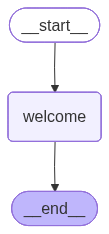

In [45]:
from IPython.display import Image, display

# Turn the builder into an executable graph
first_graph = graph.compile()

# Render the graph structure as a PNG diagram
display(Image(first_graph.get_graph().draw_mermaid_png()))

# Fallback: print Mermaid source if PNG rendering is unavailable
# print(first_graph.get_graph().draw_mermaid())

## 7. Invoke the graph

`invoke(initial_state)` runs the graph **once** from `START` to `END`.

Pass a dictionary matching `graph_schema`.  
The return value is the **final state** after all nodes have run.

In the next lessons you will add:

- Multiple nodes and conditional edges
- Reducers for merging list fields in state
- Checkpointing and human-in-the-loop patterns

In [46]:
# Run the graph with initial state; returns the final state dict
first_graph.invoke({"name": "Sajjad", "message": "Who are you?"})

{'name': 'Sajjad',
 'message': "Your message was Who are you?. Here's my response:  Hello, Sajjad! I'm Qwen, a large language model developed by Alibaba Cloud. I can assist you with a wide range of tasks, from answering questions and creating content to programming and more. How can I help you today? 😊"}